In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Dataset Column 

| Column Name | Description | 
|---|---|
| Person ID | Unique identifier for each individual | 
| Gender | Gender of the individual | 
| Age | Age of the individual | 
| Occupation | Profession of the individual | 
| Sleep Duration | Average number of hours the person sleeps per day |
| Quality of Sleep | Self-rated quality of sleep | 
| Physical Activity Level | Number of minutes spent on physical activity per day | 
| Stress Level | Self-rated stress level | 
| BMI Category | Body Mass Index category |
| Blood Pressure | Blood pressure reading (Systolic/Diastolic) | 
| Heart Rate | Resting heart rate | 
| Daily Steps | Average number of steps taken per day | 
| Sleep Disorder | Presence of a diagnosed sleep disorder |

In [2]:
df = pd.read_csv('sleep.csv')
df.head(20)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN


## Data Cleaning 

In [3]:
df.shape

(374, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [5]:
#changing columns name
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [6]:
#Feature Engineering

df[['systolic_bp', 'diastolic_bp']] = (
    df['blood_pressure']
    .str.split('/', expand=True)
    .astype(int)
)

# Remove the original column
df.drop(columns='blood_pressure', inplace=True)

In [7]:
df.head()

,person_id,gender,age,occupation,sleep_duration,quality_of_sleep,physical_activity_level,stress_level,bmi_category,heart_rate,daily_steps,sleep_disorder,systolic_bp,diastolic_bp
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,NaN,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


In [8]:
df.describe(include='object').T

,count,unique,top,freq
gender,374,2,Male,189
occupation,374,11,Nurse,73
bmi_category,374,4,Normal,195
sleep_disorder,155,2,Sleep Apnea,78


In [9]:
df['sleep_disorder'].value_counts()

sleep_disorder
Sleep Apnea    78
Insomnia       77
Name: count, dtype: int64

In [10]:
#Handle Dupllicates
df.duplicated().sum()

np.int64(0)

In [11]:
#Checking Null Values
df.isna().sum()

person_id                    0
gender                       0
age                          0
occupation                   0
sleep_duration               0
quality_of_sleep             0
physical_activity_level      0
stress_level                 0
bmi_category                 0
heart_rate                   0
daily_steps                  0
sleep_disorder             219
systolic_bp                  0
diastolic_bp                 0
dtype: int64

In [12]:
df['sleep_disorder'] = df['sleep_disorder'].fillna('None')

In [13]:
df.isna().sum()

person_id                  0
gender                     0
age                        0
occupation                 0
sleep_duration             0
quality_of_sleep           0
physical_activity_level    0
stress_level               0
bmi_category               0
heart_rate                 0
daily_steps                0
sleep_disorder             0
systolic_bp                0
diastolic_bp               0
dtype: int64

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_id,374.0,187.500000,108.108742,1.0,94.25,187.5,280.75,374.0
age,374.0,42.184492,8.673133,27.0,35.25,43.0,50.00,59.0
sleep_duration,374.0,7.132086,0.795657,5.8,6.40,7.2,7.80,8.5
quality_of_sleep,374.0,7.312834,1.196956,4.0,6.00,7.0,8.00,9.0
physical_activity_level,374.0,59.171123,20.830804,30.0,45.00,60.0,75.00,90.0
stress_level,374.0,5.385027,1.774526,3.0,4.00,5.0,7.00,8.0
heart_rate,374.0,70.165775,4.135676,65.0,68.00,70.0,72.00,86.0
daily_steps,374.0,6816.844920,1617.915679,3000.0,5600.00,7000.0,8000.00,10000.0
systolic_bp,374.0,128.553476,7.748118,115.0,125.00,130.0,135.00,142.0
diastolic_bp,374.0,84.649733,6.161611,75.0,80.00,85.0,90.00,95.0


# Exploratory Data Analysis

## Univariate Analysis

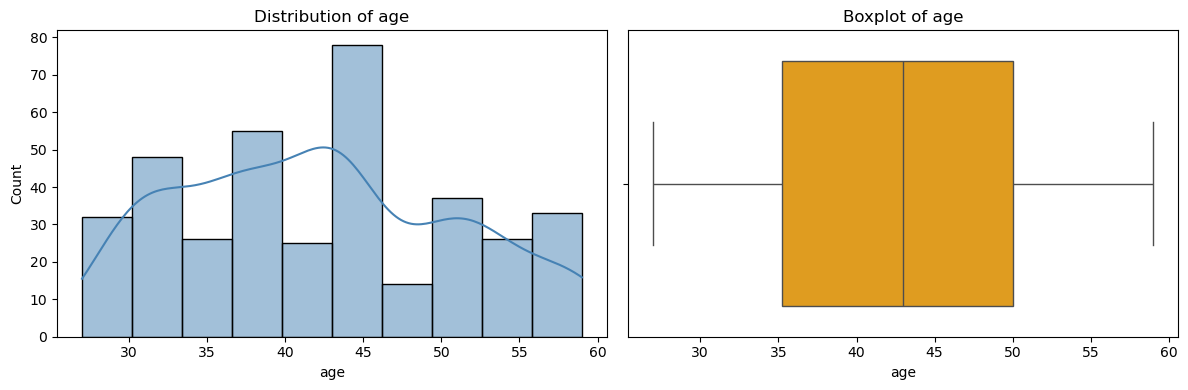

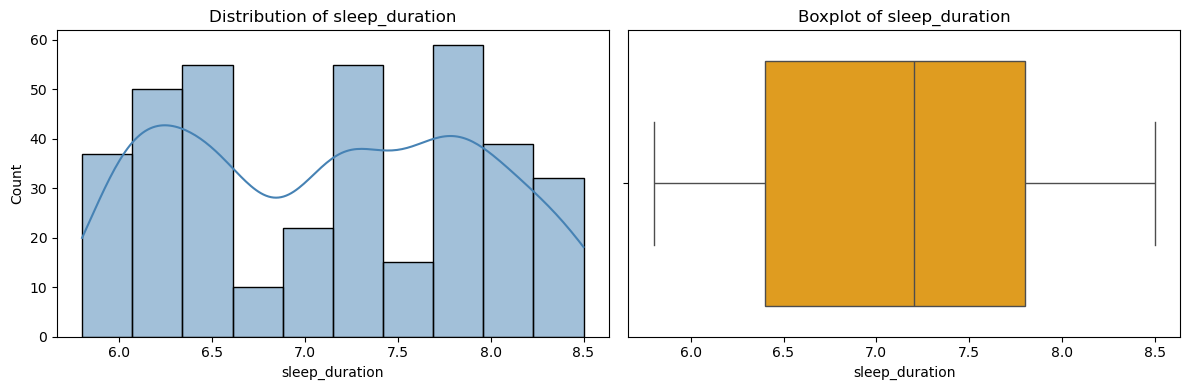

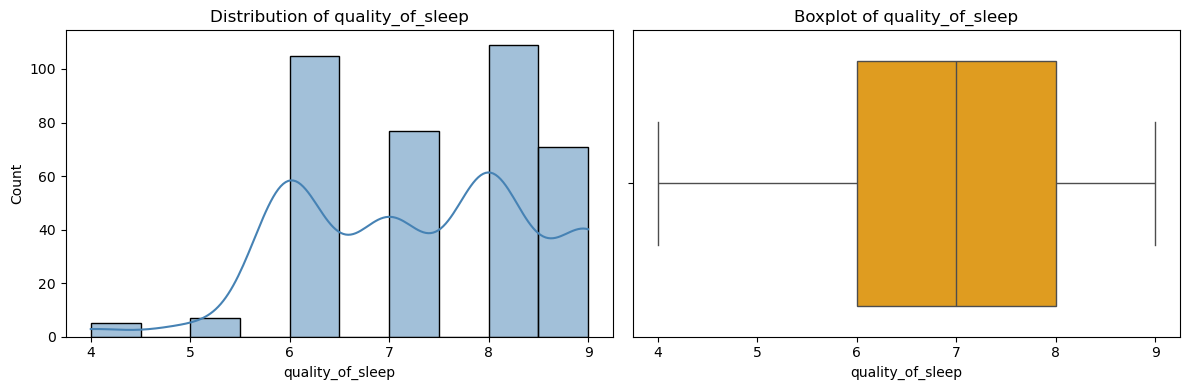

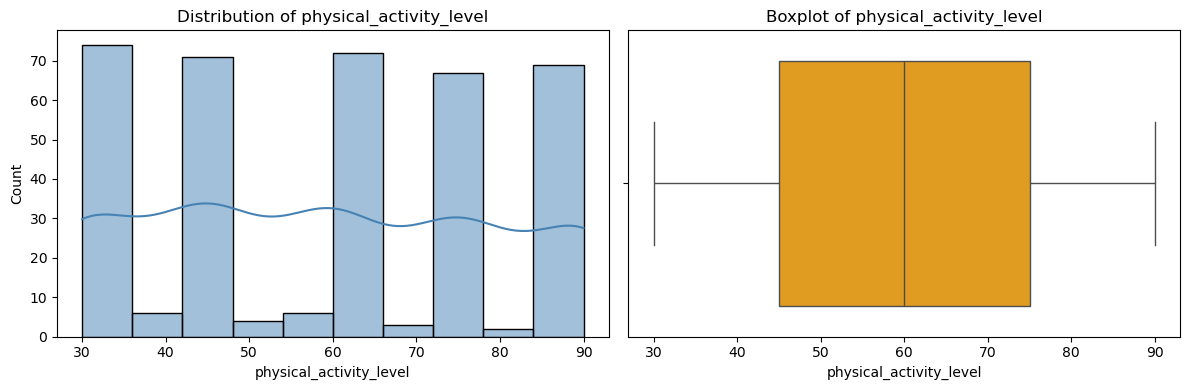

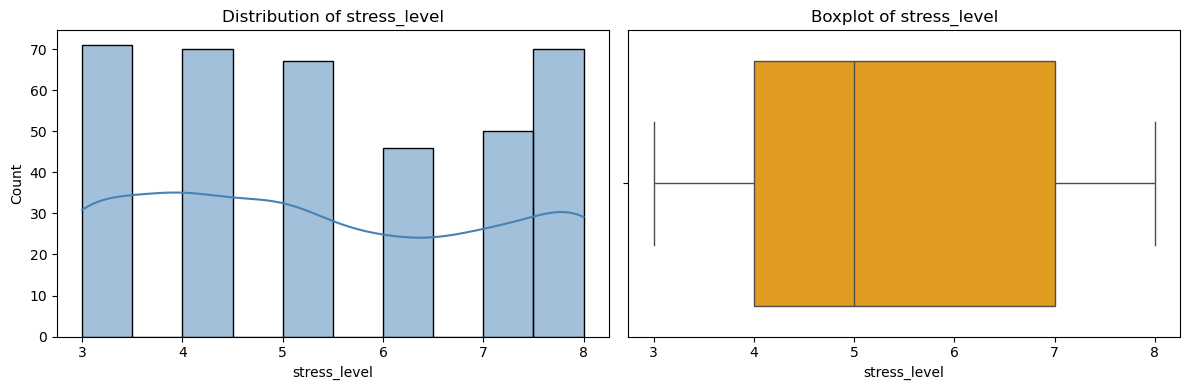

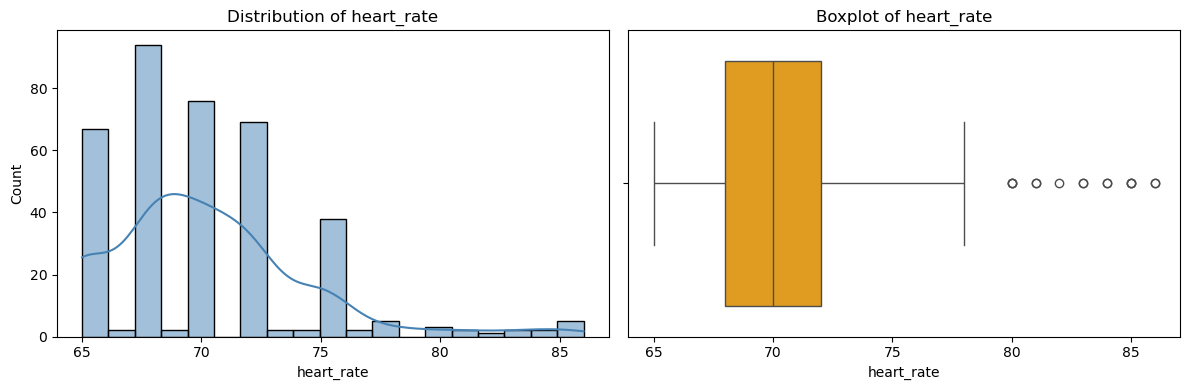

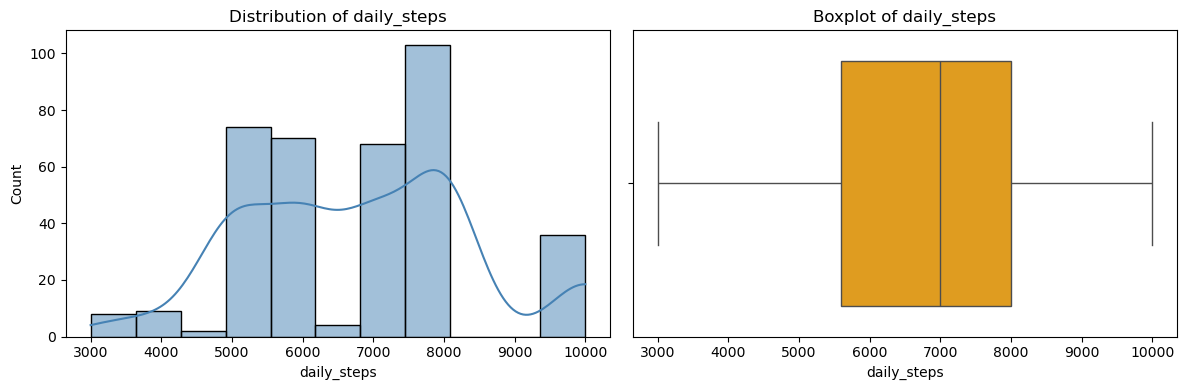

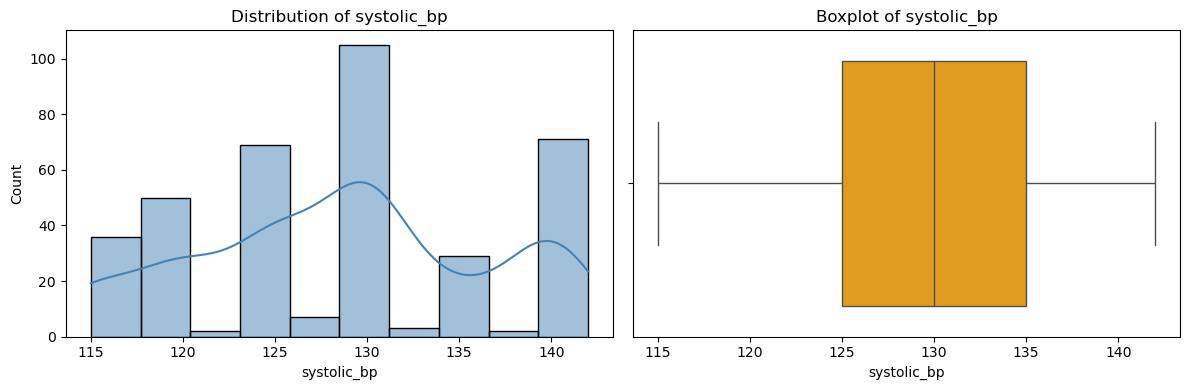

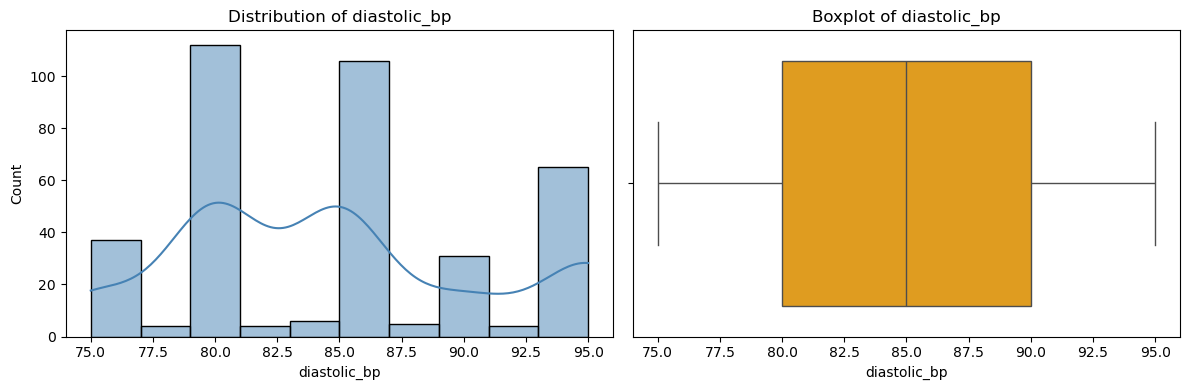

In [15]:
# select only numeric columns, drop the ID column (not meaningful for distribution)
num_cols = df.select_dtypes(include='number').columns.drop('person_id')

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # KDE + histogram
    sns.histplot(df[col], kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title(f'Distribution of {col}')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1], color='orange')
    axes[1].set_title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()

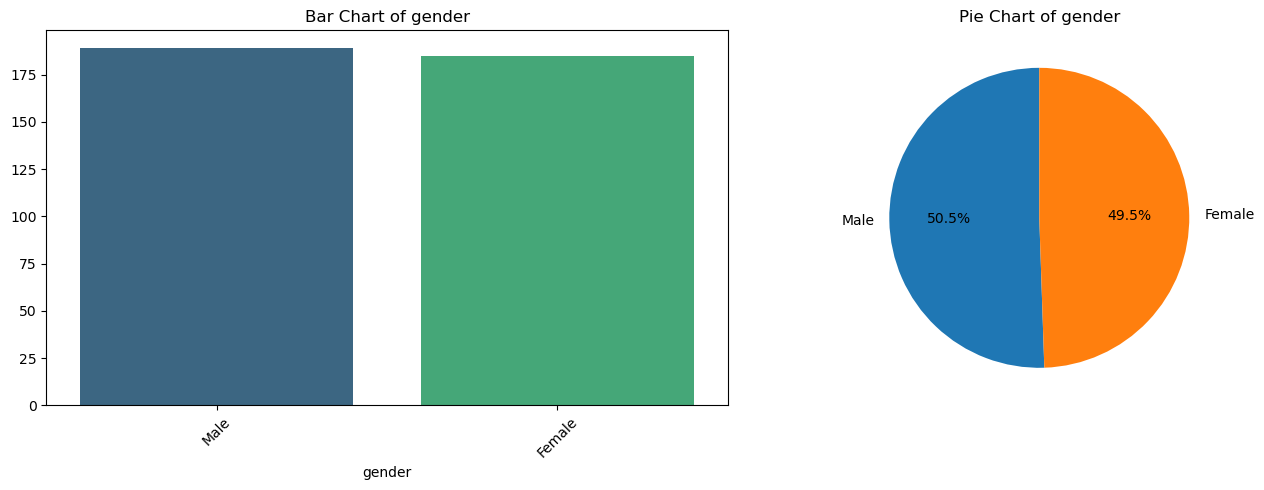

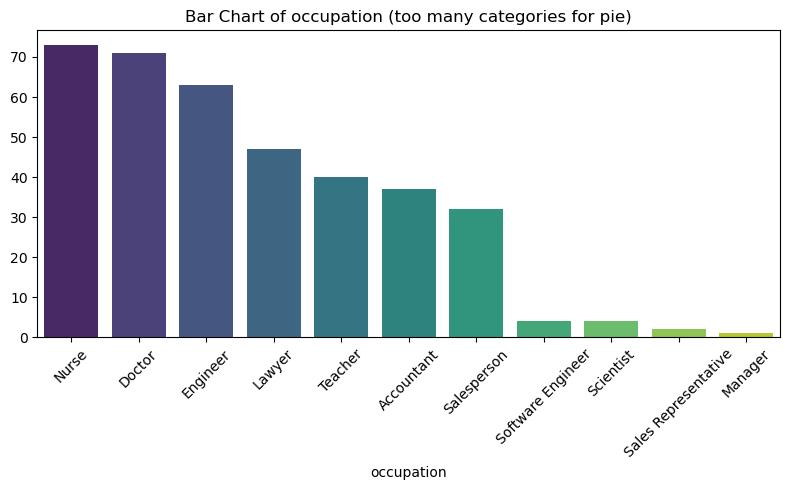

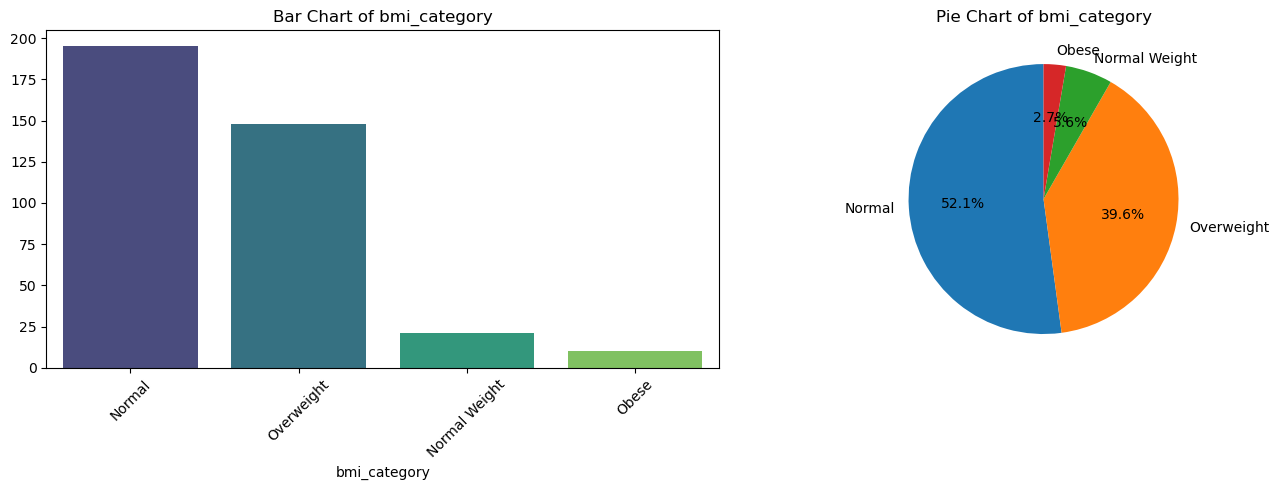

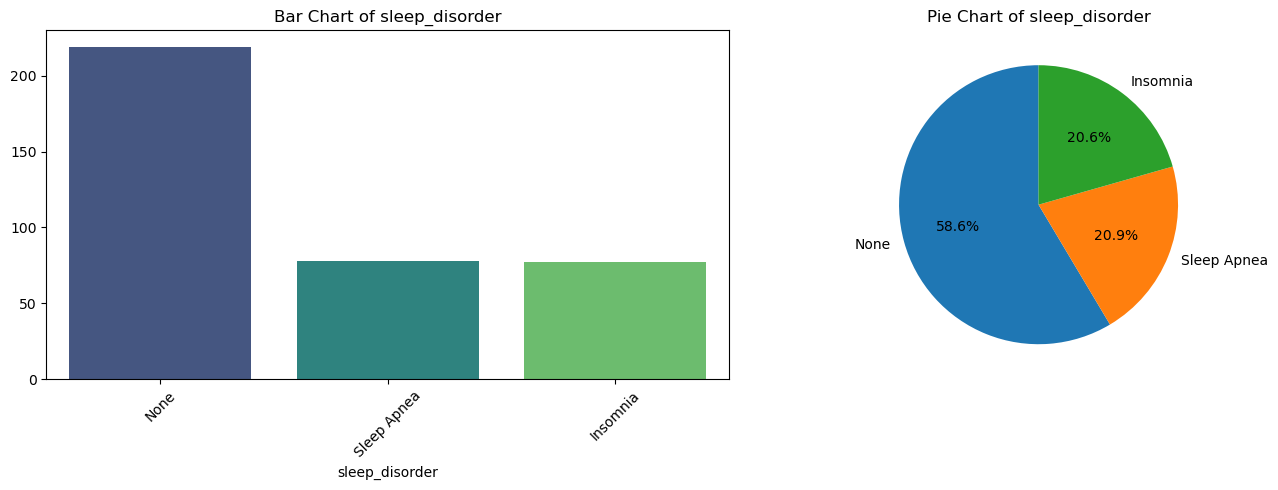

In [16]:
cat_cols = ['gender', 'occupation', 'bmi_category', 'sleep_disorder']
pie_threshold = 6  # max categories allowed for a pie chart

for col in cat_cols:
    counts = df[col].value_counts()
    
    if counts.shape[0] <= pie_threshold:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        sns.barplot(x=counts.index, y=counts.values, ax=axes[0], hue=counts.index, palette='viridis', legend=False)
        axes[0].set_title(f'Bar Chart of {col}')
        axes[0].tick_params(axis='x', rotation=45)
        
        axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90)
        axes[1].set_title(f'Pie Chart of {col}')
    else:
        fig, ax = plt.subplots(figsize=(8, 5))
        sns.barplot(x=counts.index, y=counts.values, ax=ax, hue=counts.index, palette='viridis', legend=False)
        ax.set_title(f'Bar Chart of {col} (too many categories for pie)')
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

## Univariate Analysis Insights

#### numerical
- **Age (27–59):** Evenly spread, no dominant group, no outliers.
- **Sleep Duration (5.8–8.5 hrs):** Multimodal — likely driven by occupation differences.
- **Quality of Sleep (4–9):** Skewed toward higher ratings; only a small "poor sleep" group (4–5).
- **Heart Rate:**  Only variable with visible outliers (75–86 bpm) — early signal of an at-risk subgroup.
- **Daily Steps / Physical Activity:** Multimodal, mirroring occupation-driven lifestyle differences.
- **Blood Pressure (systolic & diastolic):** Two visible clusters — normal range vs. elevated/hypertension range.

#### categorical
- Gender is balanced (50.5/49.5%).
- Occupation is heavily skewed (Nurse/Doctor/Engineer dominate).
- BMI is mostly Normal/Overweight with a very small Obese group (~2.7%).
- Sleep Disorder splits ~59% None, ~21% Sleep Apnea, ~21% Insomnia.

## Bivariate Analysis

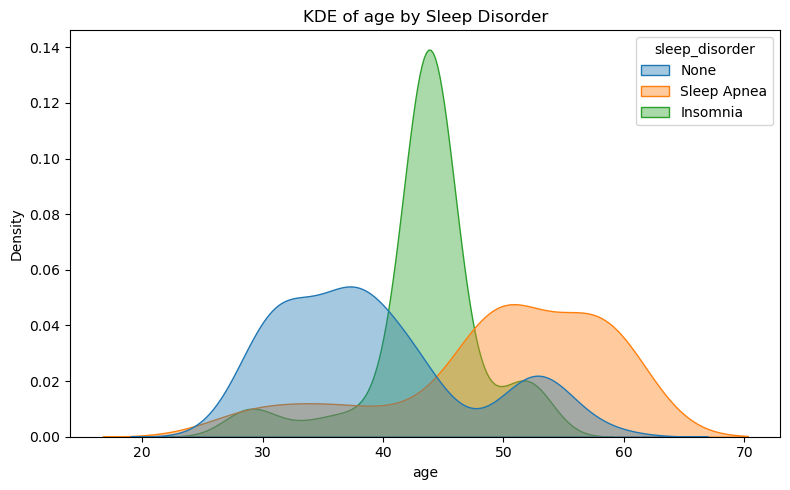

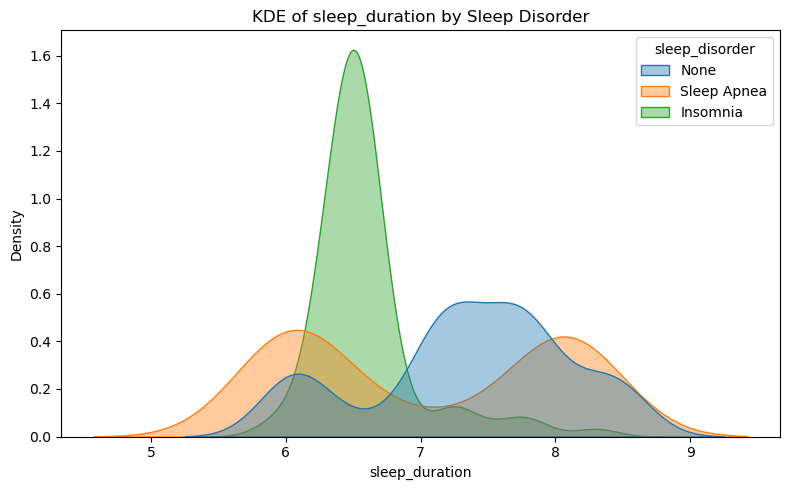

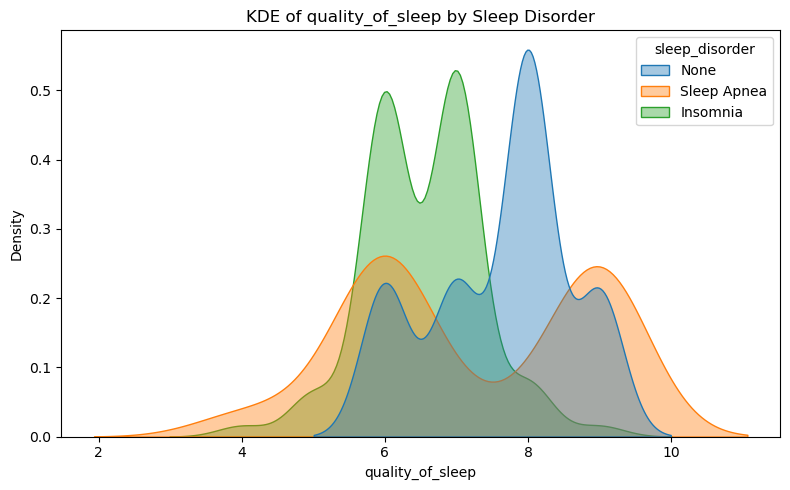

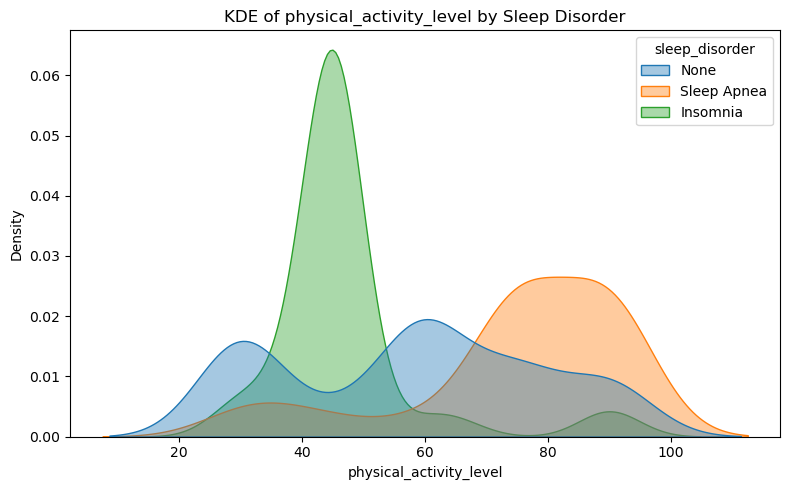

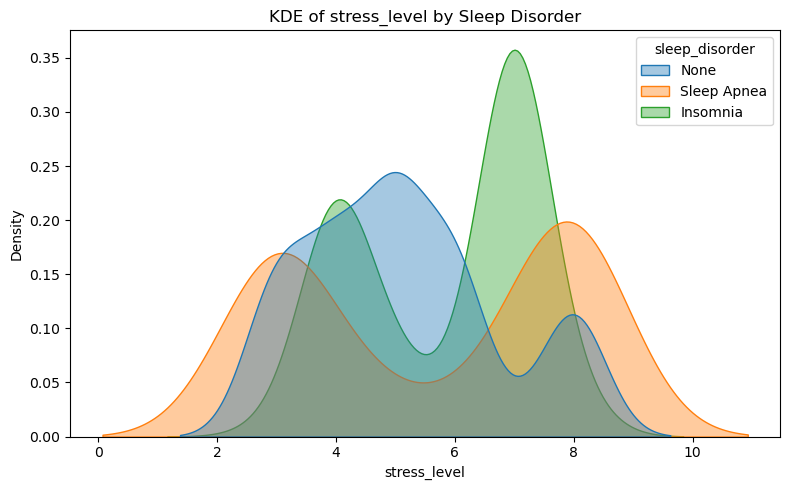

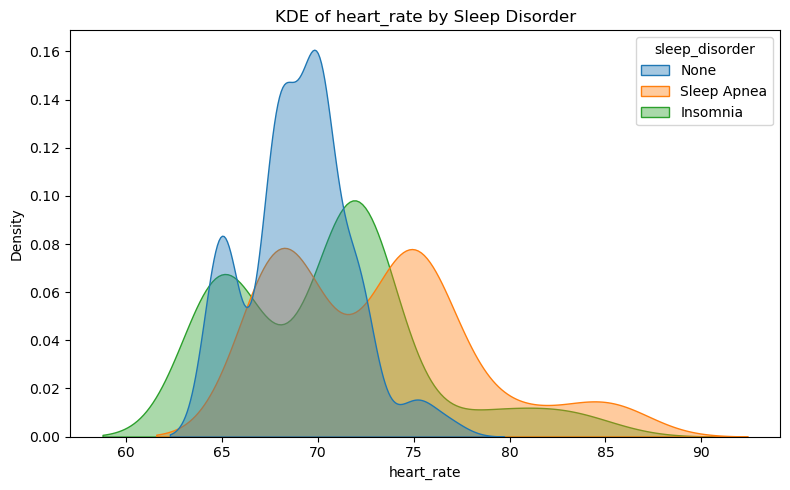

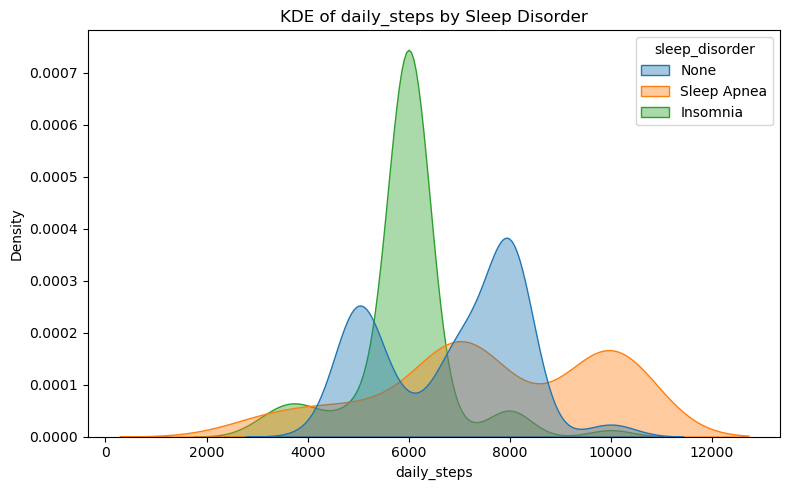

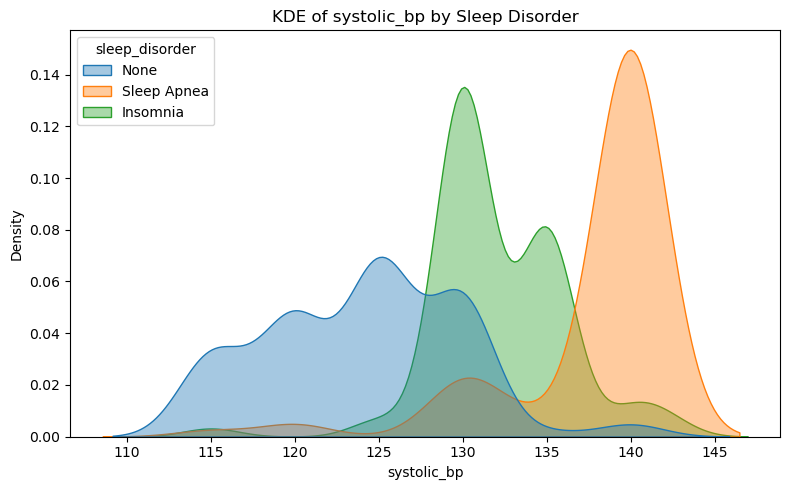

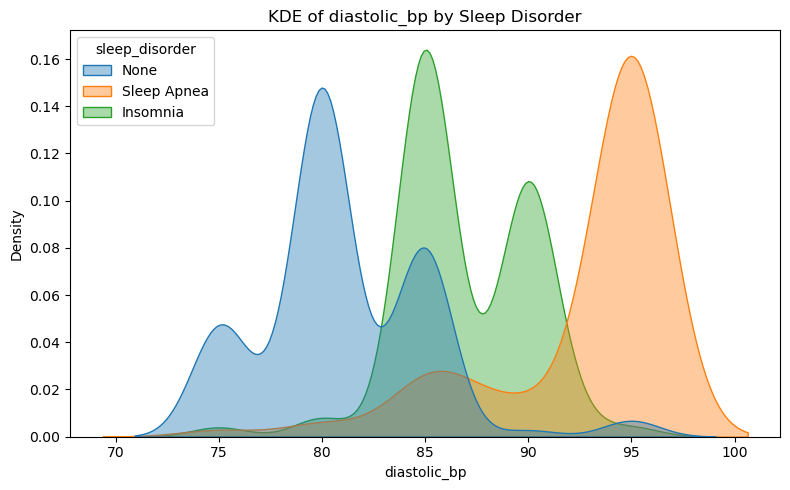

In [17]:
num_cols = df.select_dtypes(include='number').columns.drop('person_id')

for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.kdeplot(data=df, x=col, hue='sleep_disorder', fill=True, common_norm=False, alpha=0.4)
    plt.title(f'KDE of {col} by Sleep Disorder')
    plt.tight_layout()
    plt.show()

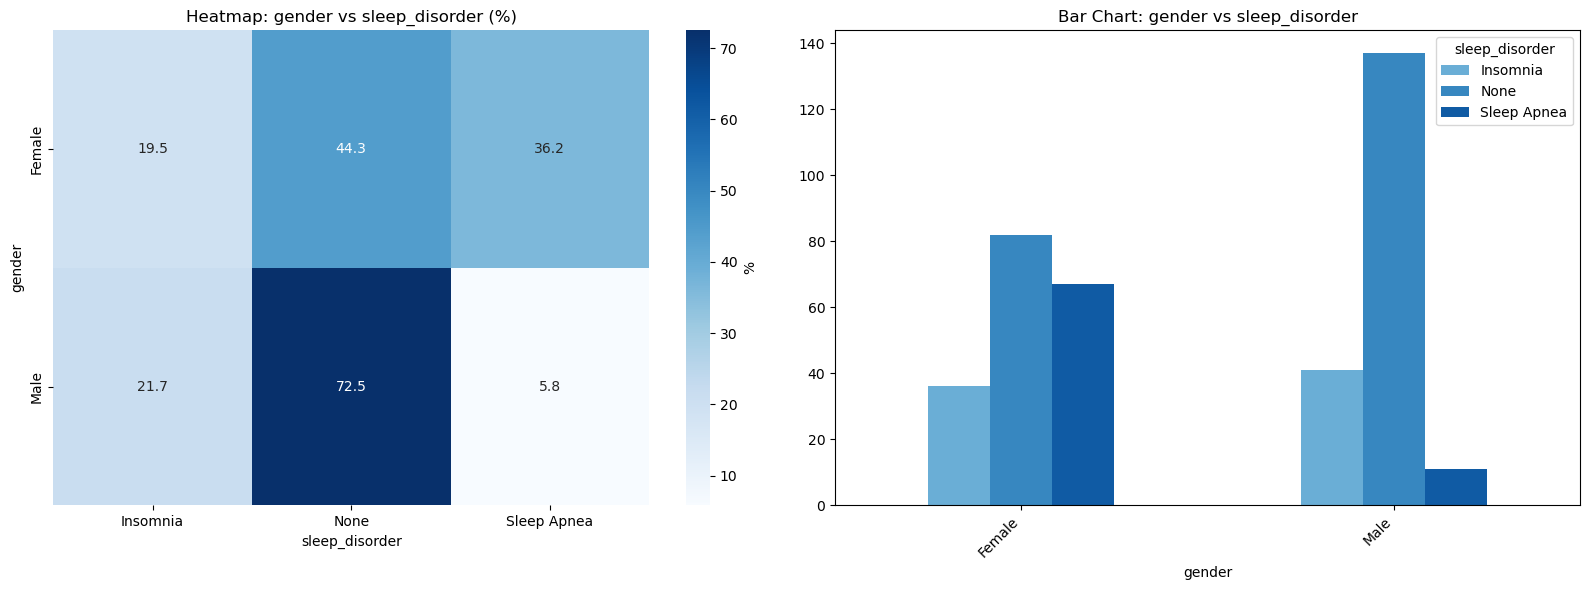

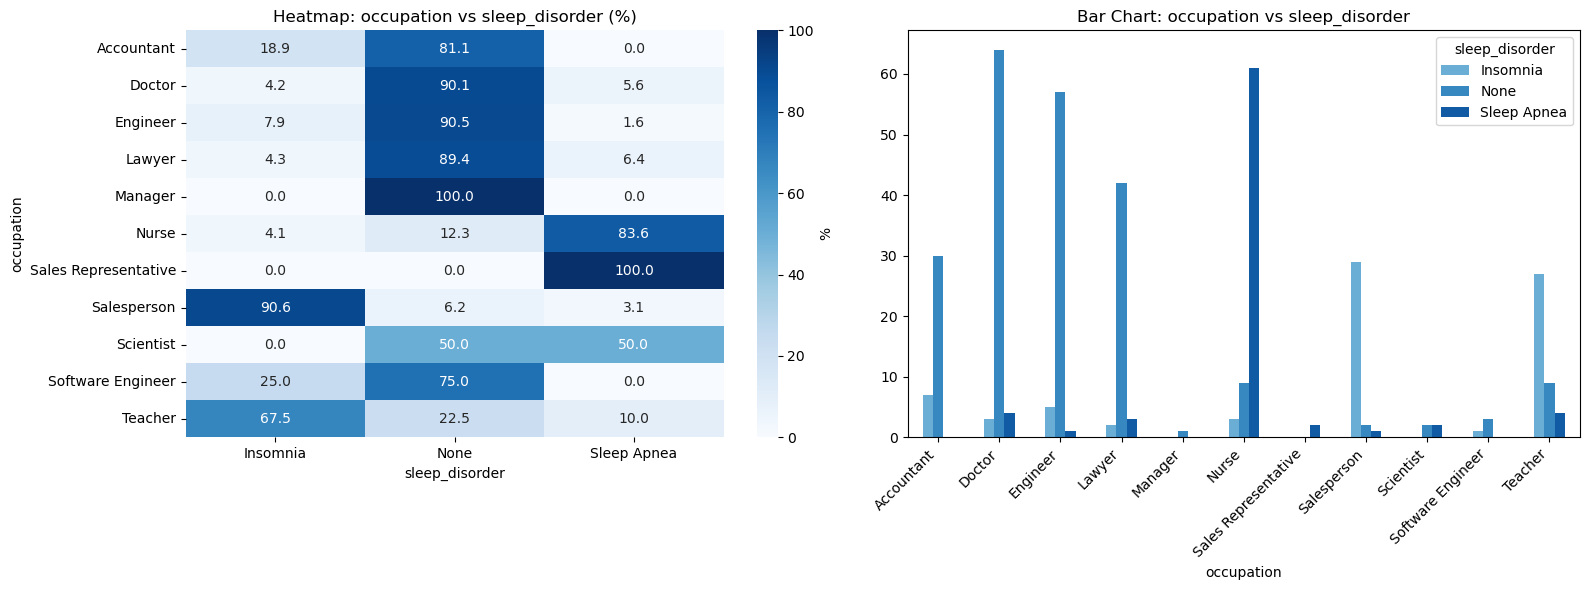

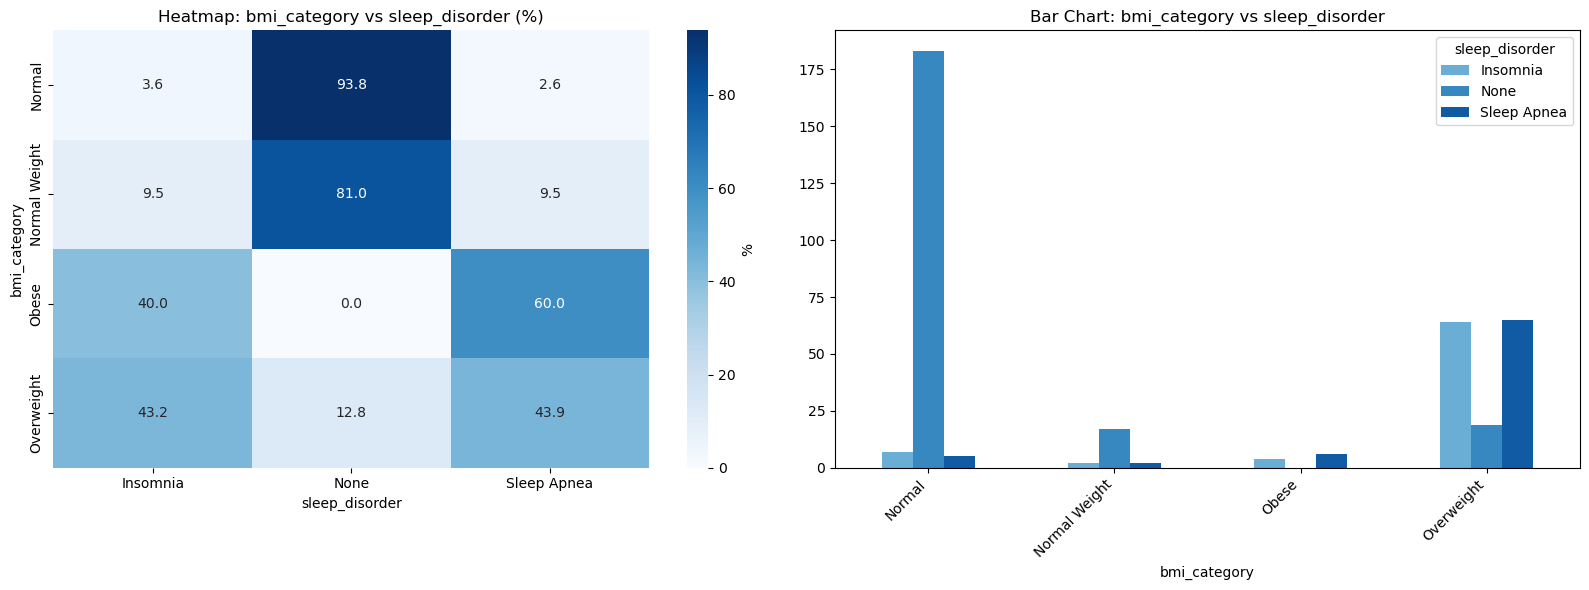

In [18]:
cat_cols = ['gender', 'occupation', 'bmi_category']
target = 'sleep_disorder'

for col in cat_cols:
    ct = pd.crosstab(df[col], df[target])
    ct_pct = pd.crosstab(df[col], df[target], normalize='index') * 100
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.heatmap(ct_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[0], cbar_kws={'label': '%'})
    axes[0].set_title(f'Heatmap: {col} vs {target} (%)')
    
    n_bars = ct.shape[1]
    blues = sns.color_palette('Blues', n_colors=n_bars + 2)[2:]
    ct.plot(kind='bar', ax=axes[1], color=blues)
    axes[1].set_title(f'Bar Chart: {col} vs {target}')
    axes[1].legend(title=target)
    
    # Fixed rotation + alignment
    for label in axes[1].get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')
    
    plt.tight_layout()
    plt.show()

## Bivariate Analysis Insights

### Numeric vs Sleep Disorder 

- **Heart Rate:** Clearest separation among all numeric features. People with **Sleep Apnea** show a visible shift toward higher heart rates (75–86 bpm), while **None** and **Insomnia** groups cluster more around 65–72 bpm. This aligns with the outliers spotted earlier in the univariate heart rate boxplot.

- **Age:** Sleep Apnea group skews older on average (49.7 yrs) compared to Insomnia (43.5 yrs) and None (39 yrs) — sleep disorders appear more common as age increases.

- **Sleep Duration:** People with **no disorder** sleep the longest on average (7.36 hrs), while **Insomnia** patients sleep the least (6.59 hrs) — expected, since insomnia directly affects ability to sleep.

- **Daily Steps:** Interestingly, the **Sleep Apnea** group has the *highest* average daily steps (7550), lower than even the "None" group (8550). This is likely confounded by occupation (Nurses walk a lot and also show very high Sleep Apnea rates).

- **Physical Activity:** Distributions overlap more across groups — but people who have around(40-50) min have high chance of Insomnia and who have around(70-90) min have high chance of Sleep Apnea.

-  **Stress Level:** Distributions overlap more across groups — but people who having 7 stress_level as average min have high chance of Insomnia and as the stress_level increase chances of Sleep Apnea increases and having stress_level around (5-6) have no disorder.

### Categorical vs Sleep Disorder 

- **BMI Category:**
  - **Normal** BMI → 92.6% have **no disorder** — strongest protective pattern in the dataset.
  - **Obese** → 60% have **Sleep Apnea**, 40% have **Insomnia**, 0% have none — small sample size (10 people) but a striking 100% disorder rate.
  - **Overweight** → disorders roughly split between Insomnia (43.2%) and Sleep Apnea (43.9%), with only 12.8% having none.
  - **Takeaway:** Higher BMI category is strongly associated with having *some* sleep disorder.

- **Gender:**
  - **Males:** 72.5% have no disorder, only 5.8% have Sleep Apnea.
  - **Females:** Only 44.3% have no disorder; 36.2% have Sleep Apnea — a much higher rate than males.
  - **Takeaway:** Sleep Apnea appears far more prevalent among females in this dataset, which is worth flagging as a notable (and somewhat counterintuitive, since Sleep Apnea is often reported as more common in men) pattern.

- **Occupation:**
  - **Nurses** stand out sharply — 83.6% have Sleep Apnea, far above any other profession.
  - **Salespersons** and **Teachers** show high Insomnia rates (90.6% and 67.5% respectively).
  - **Doctors, Engineers, Lawyers, Managers, Accountants** mostly fall in the "None" category (80–100%).
  


## Multivariate Analysis

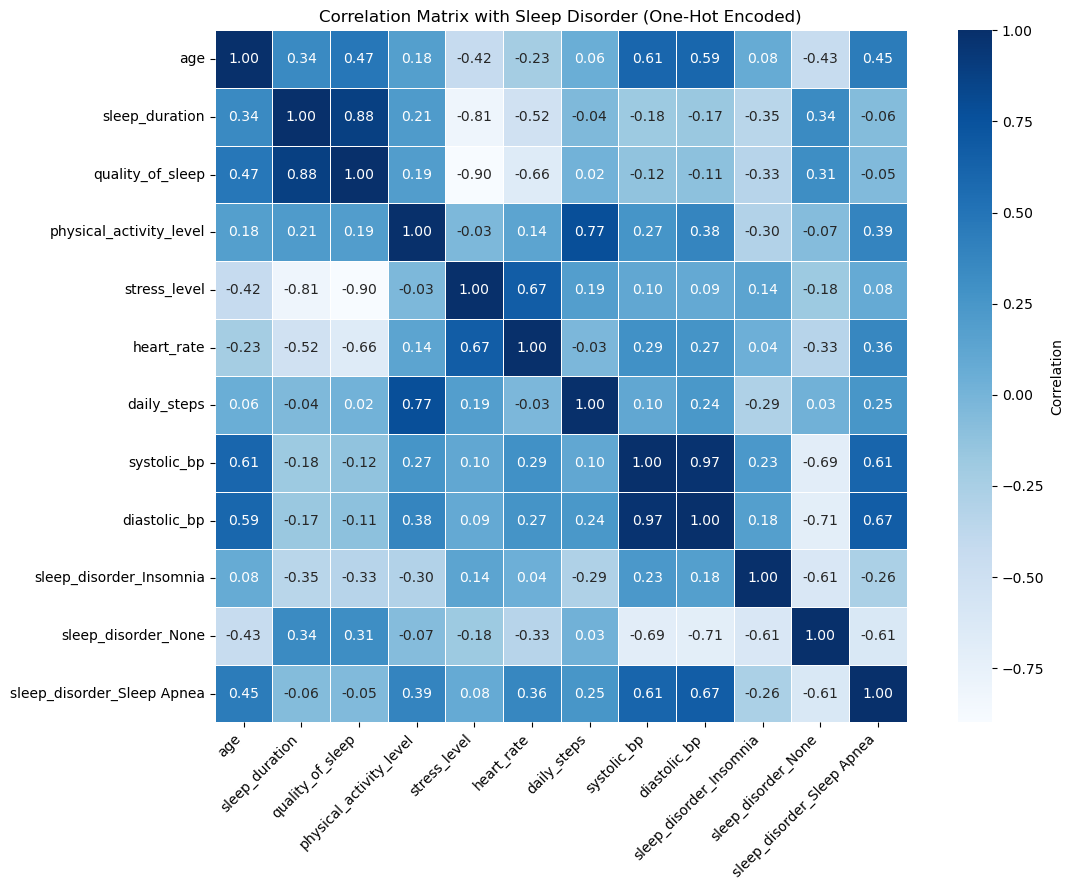

In [19]:
num_cols = df.select_dtypes(include='number').columns.drop('person_id').tolist()

# one-hot encode sleep_disorder and add to numeric columns
df_encoded = pd.concat([df[num_cols], pd.get_dummies(df['sleep_disorder'], prefix='sleep_disorder')], axis=1)

corr = df_encoded.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', square=True, 
            linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix with Sleep Disorder (One-Hot Encoded)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Multivarite Analysis Insights

- **`sleep_duration` ↔ `quality_of_sleep`: +0.88** — the strongest relationship in the entire dataset; more sleep hours strongly drive better sleep quality ratings.
- **`stress_level` ↔ `quality_of_sleep`: -0.90** and **`stress_level` ↔ `sleep_duration`: -0.81** — stress is the single biggest lifestyle factor degrading sleep, even stronger than physical activity.
- **`systolic_bp` ↔ `diastolic_bp`: +0.97** — expected, since both measure the same underlying blood pressure system.
- **Blood pressure is the strongest driver of Sleep Apnea:** `diastolic_bp` (+0.67) and `systolic_bp` (+0.61) correlate more strongly with Sleep Apnea than any other numeric feature — stronger even than BMI category alone.
- **`age` ↔ Sleep Apnea: +0.45** and **`age` ↔ blood pressure: ~0.6** — age drives both BP and Sleep Apnea risk together, suggesting age is a shared underlying factor.
- **`physical_activity_level` ↔ `daily_steps`: +0.77** — as expected, these two variables measure closely related behavior (redundant if used together in modeling).
- **`heart_rate` ↔ `stress_level`: +0.67** — higher stress associates with higher resting heart rate, reinforcing the stress-cardiovascular-sleep link.


## Conclusion 

- People with **higher BMI** (Overweight/Obese) are much more likely to have a sleep disorder.

- **Higher blood pressure** is strongly linked to Sleep Apnea.

- **Older age** is linked to more Sleep Apnea cases.

- **Higher heart rate** is also linked to Sleep Apnea.

- **More stress** leads to shorter and lower-quality sleep, but doesn't tell us which disorder someone has.

- **Occupation** shows patterns (e.g., Nurses have more Sleep Apnea), but this is probably because of BMI/age, not the job itself.

- **Gender and daily steps** don't show a clear, reliable pattern — not strong predictors.

- **Sleep duration and sleep quality move together** — more sleep hours usually means better sleep quality.

### For Model Building
- **Strong features to use:** `bmi_category`, `systolic_bp`, `diastolic_bp`, `age`, `heart_rate`
- **Weak/unclear features:** `gender`, `daily_steps`, `physical_activity_level`
- **Watch for redundancy:** `systolic_bp` & `diastolic_bp` are almost identical (correlation 0.97) — consider using only one; same for `physical_activity_level` & `daily_steps` (correlation 0.77).


In [20]:
df.head()

,person_id,gender,age,occupation,sleep_duration,quality_of_sleep,physical_activity_level,stress_level,bmi_category,heart_rate,daily_steps,sleep_disorder,systolic_bp,diastolic_bp
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,None,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


In [21]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['occupation'] = le.fit_transform(df['occupation'])
df['bmi_category'] = le.fit_transform(df['bmi_category'])

In [22]:
df.head()

,person_id,gender,age,occupation,sleep_duration,quality_of_sleep,physical_activity_level,stress_level,bmi_category,heart_rate,daily_steps,sleep_disorder,systolic_bp,diastolic_bp
0,1,1,27,9,6.1,6,42,6,3,77,4200,None,126,83
1,2,1,28,1,6.2,6,60,8,0,75,10000,None,125,80
2,3,1,28,1,6.2,6,60,8,0,75,10000,None,125,80
3,4,1,28,6,5.9,4,30,8,2,85,3000,Sleep Apnea,140,90
4,5,1,28,6,5.9,4,30,8,2,85,3000,Sleep Apnea,140,90


In [23]:
cols = list(df.columns)
cols

['person_id',
 'gender',
 'age',
 'occupation',
 'sleep_duration',
 'quality_of_sleep',
 'physical_activity_level',
 'stress_level',
 'bmi_category',
 'heart_rate',
 'daily_steps',
 'sleep_disorder',
 'systolic_bp',
 'diastolic_bp']

In [24]:
len(cols)

14

In [25]:
cols.index('sleep_disorder')

11

In [26]:
cols.pop(0)

'person_id'

In [27]:
cols.remove('sleep_disorder')

In [28]:
cols

['gender',
 'age',
 'occupation',
 'sleep_duration',
 'quality_of_sleep',
 'physical_activity_level',
 'stress_level',
 'bmi_category',
 'heart_rate',
 'daily_steps',
 'systolic_bp',
 'diastolic_bp']

In [29]:
len(cols)

12

In [30]:
x= df.loc[:,cols]
x

,gender,age,occupation,sleep_duration,quality_of_sleep,physical_activity_level,stress_level,bmi_category,heart_rate,daily_steps,systolic_bp,diastolic_bp
0,1,27,9,6.1,6,42,6,3,77,4200,126,83
1,1,28,1,6.2,6,60,8,0,75,10000,125,80
2,1,28,1,6.2,6,60,8,0,75,10000,125,80
3,1,28,6,5.9,4,30,8,2,85,3000,140,90
4,1,28,6,5.9,4,30,8,2,85,3000,140,90
...,...,...,...,...,...,...,...,...,...,...,...,...
369,0,59,5,8.1,9,75,3,3,68,7000,140,95
370,0,59,5,8.0,9,75,3,3,68,7000,140,95
371,0,59,5,8.1,9,75,3,3,68,7000,140,95
372,0,59,5,8.1,9,75,3,3,68,7000,140,95


In [31]:
x.shape

(374, 12)

In [32]:
y=df.loc[:,'sleep_disorder']
y

0             None
1             None
2             None
3      Sleep Apnea
4      Sleep Apnea
          ...     
369    Sleep Apnea
370    Sleep Apnea
371    Sleep Apnea
372    Sleep Apnea
373    Sleep Apnea
Name: sleep_disorder, Length: 374, dtype: object

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   person_id                374 non-null    int64  
 1   gender                   374 non-null    int64  
 2   age                      374 non-null    int64  
 3   occupation               374 non-null    int64  
 4   sleep_duration           374 non-null    float64
 5   quality_of_sleep         374 non-null    int64  
 6   physical_activity_level  374 non-null    int64  
 7   stress_level             374 non-null    int64  
 8   bmi_category             374 non-null    int64  
 9   heart_rate               374 non-null    int64  
 10  daily_steps              374 non-null    int64  
 11  sleep_disorder           374 non-null    object 
 12  systolic_bp              374 non-null    int64  
 13  diastolic_bp             374 non-null    int64  
dtypes: float64(1), int64(12), 

## Data Splitting 

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
xtrain, xtest, ytrain, ytest = train_test_split(x,y, test_size=0.2, random_state=42)

In [36]:
xtrain.shape

(299, 12)

In [37]:
xtest.shape

(75, 12)

In [38]:
ytrain.shape

(299,)

In [39]:
ytest.shape

(75,)

## KNN Model

In [51]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,f1_score

# --- Train KNN model ---
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(xtrain, ytrain)

# --- Predict ---
ypredict_knn = knn_model.predict(xtest)

# --- Evaluate ---
acc_knn = accuracy_score(y_true=ytest, y_pred=ypredict_knn)
err_knn = 1 - acc_knn
precision_knn = precision_score(ytest, ypredict_knn, average='weighted')
recall_knn = recall_score(ytest, ypredict_knn, average='weighted')
f1_knn = f1_score(ytest, ypredict_knn, average='weighted')

print('Accuracy:', round(acc_knn, 3))
print('Error:', round(err_knn, 3))
print("Precision:", round(precision_knn, 3))
print("Recall   :", round(recall_knn, 3))
print("F1 Score :", round(f1_knn, 3))

print()
print('Confusion Matrix:')
print(confusion_matrix(y_true=ytest, y_pred=ypredict_knn))

print()
print('Classification Report:')
print(classification_report(y_true=ytest, y_pred=ypredict_knn))

Accuracy: 0.867
Error: 0.133
Precision: 0.883
Recall   : 0.867
F1 Score : 0.866

Confusion Matrix:
[[14  1  1]
 [ 2 41  0]
 [ 5  1 10]]

Classification Report:
              precision    recall  f1-score   support

    Insomnia       0.67      0.88      0.76        16
        None       0.95      0.95      0.95        43
 Sleep Apnea       0.91      0.62      0.74        16

    accuracy                           0.87        75
   macro avg       0.84      0.82      0.82        75
weighted avg       0.88      0.87      0.87        75



In [44]:
ytest.value_counts()

sleep_disorder
None           43
Insomnia       16
Sleep Apnea    16
Name: count, dtype: int64

In [ ]:
pd.Series(ypredict).value_counts()

## Support Vector Machine 

In [52]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix, f1_score


# --- Train SVM ---
model = SVC(kernel='rbf', random_state=42)
model.fit(xtrain, ytrain)

# --- Predict & evaluate ---
ypredict_svm = model.predict(xtest)

acc_svm = accuracy_score(ytest, ypredict_svm)
err_svm = 1 - acc_svm
precision_svm = precision_score(ytest, ypredict_svm, average='weighted')
recall_svm = recall_score(ytest, ypredict_svm, average='weighted')
f1_svm = f1_score(ytest, ypredict_svm, average='weighted')

print('Accuracy:', round(acc_svm,3))
print('Error:', round(err_svm, 3))
print("Precision:", round(precision_svm, 3))
print("Recall   :", round(recall_svm, 3))
print("F1 Score :", round(f1_svm, 3))

print()
print(classification_report(ytest, ypredict_svm))
print(confusion_matrix(ytest, ypredict_svm))

Accuracy: 0.64
Error: 0.36
Precision: 0.598
Recall   : 0.64
F1 Score : 0.555

              precision    recall  f1-score   support

    Insomnia       0.25      0.06      0.10        16
        None       0.65      1.00      0.79        43
 Sleep Apnea       0.80      0.25      0.38        16

    accuracy                           0.64        75
   macro avg       0.57      0.44      0.42        75
weighted avg       0.60      0.64      0.55        75

[[ 1 14  1]
 [ 0 43  0]
 [ 3  9  4]]


## Decision Tree Model

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix, f1_score


# --- Train Decision Tree ---
model = DecisionTreeClassifier(random_state=42)
model.fit(xtrain, ytrain)

# --- Predict & evaluate ---
ypredict_decision_tree = model.predict(xtest)

acc_decision_tree = accuracy_score(ytest, ypredict_decision_tree)
err_decision_tree = 1 - acc_decision_tree
precision_decision_tree = precision_score(ytest, ypredict_decision_tree, average='weighted')
recall_decision_tree = recall_score(ytest, ypredict_decision_tree, average='weighted')
f1_decision_tree = f1_score(ytest, ypredict_decision_tree, average='weighted')


print('Accuracy:', round(acc_decision_tree,2))
print('Error:', round(err_decision_tree, 2))
print("Precision:", round(precision_decision_tree, 3))
print("Recall   :", round(recall_decision_tree, 3))
print("F1 Score :", round(f1_decision_tree, 3))

print()
print(classification_report(ytest, ypredict_decision_tree))
print(confusion_matrix(ytest, ypredict_decision_tree))

# --- Bonus: feature importance (Decision Trees give you this for free) ---
importances = pd.Series(model.feature_importances_, index=x.columns).sort_values(ascending=False)
print(importances)

Accuracy: 0.89
Error: 0.11
Precision: 0.893
Recall   : 0.893
F1 Score : 0.892

              precision    recall  f1-score   support

    Insomnia       0.76      0.81      0.79        16
        None       0.95      0.98      0.97        43
 Sleep Apnea       0.86      0.75      0.80        16

    accuracy                           0.89        75
   macro avg       0.86      0.85      0.85        75
weighted avg       0.89      0.89      0.89        75

[[13  1  2]
 [ 1 42  0]
 [ 3  1 12]]
bmi_category               0.495228
physical_activity_level    0.285737
systolic_bp                0.078103
age                        0.051623
heart_rate                 0.028913
sleep_duration             0.021006
gender                     0.015157
diastolic_bp               0.013947
daily_steps                0.005412
stress_level               0.002526
occupation                 0.002348
quality_of_sleep           0.000000
dtype: float64


## Random Forest Model

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix, f1_score


# --- Train Random Forest ---
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(xtrain, ytrain)

# --- Predict & evaluate ---
ypredict_random_forest = model.predict(xtest)

acc_random_forest = accuracy_score(ytest, ypredict_random_forest)
err_random_forest = 1 - acc_random_forest
precision_random_forest = precision_score(ytest, ypredict_random_forest, average='weighted')
recall_random_forest = recall_score(ytest, ypredict_random_forest, average='weighted')
f1_random_forest = f1_score(ytest, ypredict_random_forest, average='weighted')


print('Accuracy:', round(acc_random_forest,2))
print('Error:', round(err_random_forest, 2))
print("Precision:", round(precision_random_forest, 3))
print("Recall   :", round(recall_random_forest, 3))
print("F1 Score :", round(f1_random_forest, 3))

print()
print(classification_report(ytest, ypredict_random_forest))
print(confusion_matrix(ytest, ypredict_random_forest))

# --- Feature importance ---
importances = pd.Series(model.feature_importances_, index=x.columns).sort_values(ascending=False)
print(importances)

Accuracy: 0.88
Error: 0.12
Precision: 0.882
Recall   : 0.88
F1 Score : 0.879

              precision    recall  f1-score   support

    Insomnia       0.72      0.81      0.76        16
        None       0.95      0.98      0.97        43
 Sleep Apnea       0.85      0.69      0.76        16

    accuracy                           0.88        75
   macro avg       0.84      0.83      0.83        75
weighted avg       0.88      0.88      0.88        75

[[13  1  2]
 [ 1 42  0]
 [ 4  1 11]]
bmi_category               0.171773
diastolic_bp               0.155713
systolic_bp                0.153752
occupation                 0.109795
sleep_duration             0.093992
age                        0.090871
physical_activity_level    0.075859
daily_steps                0.057726
heart_rate                 0.032636
stress_level               0.030016
quality_of_sleep           0.023268
gender                     0.004599
dtype: float64


# Model Comparison

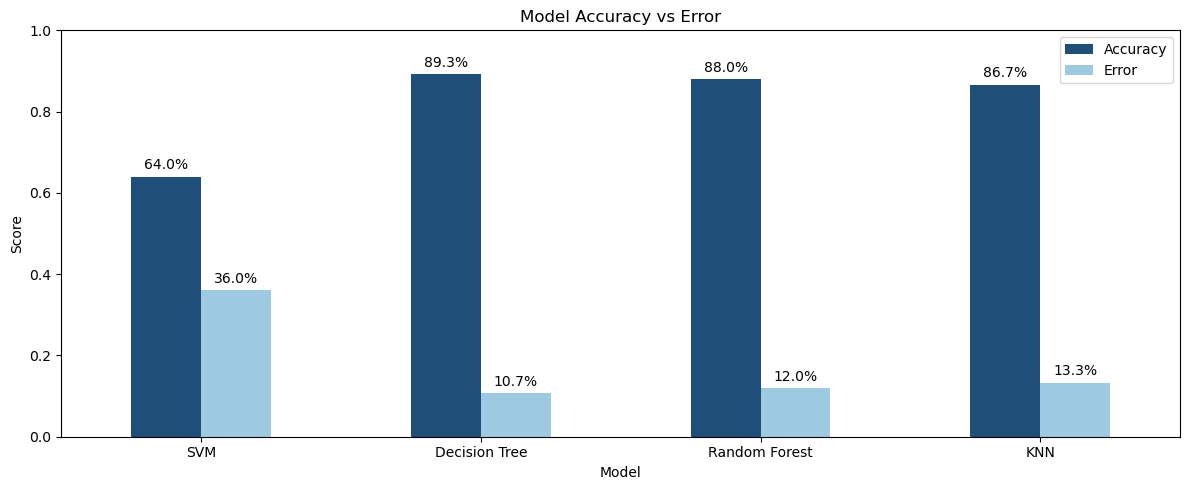

In [48]:
results = pd.DataFrame({
    'Model': ['SVM', 'Decision Tree', 'Random Forest', 'KNN'],
    'Accuracy': [acc_svm, acc_decision_tree, acc_random_forest, acc_knn],
    'Error': [err_svm, err_decision_tree, err_random_forest, err_knn]
})


ax = results.plot(
    x='Model',
    y=['Accuracy', 'Error'],
    kind='bar',
    color=['#1f4e79', '#9ecae1'],
    figsize=(12, 5)
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{value:.1%}' for value in container.datavalues],
        padding=3
    )

plt.title('Model Accuracy vs Error')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
models_preds = {
    'SVM': ypredict_svm,
    'Decision Tree': ypredict_decision_tree,
    'Random Forest': ypredict_random_forest,
    'KNN': ypredict_knn
}

for name, preds in models_preds.items():
    cm = confusion_matrix(ytest, preds)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()